# Q3. Feature Engineering and Regression Pipeline 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# scikit-learn tools 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# Load Data
df = pd.read_csv('q3_retail_promotions.csv')

print('Dataset Shape:', df.shape)   # (rows, columns)
print()
print('Column Names:')
print(df.columns.tolist())

Dataset Shape: (1200, 9)

Column Names:
['transaction_date', 'store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'items_sold']


In [3]:
print('Data Types & Missing Value Info:')
df.info()

Data Types & Missing Value Info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   transaction_date     1200 non-null   str  
 1   store_id             1200 non-null   int64
 2   store_size           1200 non-null   str  
 3   location_type        1200 non-null   str  
 4   promotion_type       1200 non-null   str  
 5   is_weekend           1200 non-null   int64
 6   is_festival          1200 non-null   int64
 7   competition_density  1200 non-null   int64
 8   items_sold           1200 non-null   int64
dtypes: int64(5), str(4)
memory usage: 84.5 KB


In [4]:
print('First 5 rows:')
df.head()

First 5 rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


## 1. Date Feature Engineering

In [5]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])# Converting the date column from text to an actual datetime object

#Extracting date parts
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek  

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int) #creating is_month_end.if day >= 25 → 1 (True), else → 0 (False)

print('New columns:', ['year', 'month', 'day_of_week', 'is_month_end'])


New columns: ['year', 'month', 'day_of_week', 'is_month_end']


In [6]:
#Display a sample of the dataframe to confirm new columns

cols_to_show = ['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']
print('Sample rows showing new date features:')
df[cols_to_show].head(10)

Sample rows showing new date features:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181


##  Temporal Train-Test Split 

##### Why a random split is inappropriate for time-ordered data.
For example: 
    
- If the dataset goes from Jan 2022 to Dec 2024.  
With a random split, the training set might include rows from Dec 2024 and the test set might include rows from Jan 2022.

- That means the model would be predicting the past using the future. 
    This can also lead to **data leakage**.

Hence we use Temporal split where we sort by date. So we train on early data and test on later data.


In [7]:
# Sorting the entire dataframe by date (oldest first)
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

print('Date range in dataset:')
print('  Earliest date:', df_sorted['transaction_date'].min().date())
print('  Latest date  :', df_sorted['transaction_date'].max().date())
print('  Total rows   :', len(df_sorted))

Date range in dataset:
  Earliest date: 2022-01-01
  Latest date  : 2024-12-31
  Total rows   : 1200


In [8]:
# Calculating the split index
# 80% for training, 20% for testing

total_rows   = len(df_sorted)
split_index  = int(total_rows * 0.80)  

print(f'Total rows       : {total_rows}')
print(f'Split at index   : {split_index}')
print(f'Training rows    : {split_index}  (rows 0 to {split_index-1})')
print(f'Test rows        : {total_rows - split_index}  (rows {split_index} to {total_rows-1})')

Total rows       : 1200
Split at index   : 960
Training rows    : 960  (rows 0 to 959)
Test rows        : 240  (rows 960 to 1199)


In [9]:
#Creating train and test sets
train_df = df_sorted.iloc[:split_index]    # first 80%
test_df  = df_sorted.iloc[split_index:]    # last 20%

print('Train set date range:', train_df['transaction_date'].min().date(),
      'to', train_df['transaction_date'].max().date())
print('Test set date range :', test_df['transaction_date'].min().date(),
      'to', test_df['transaction_date'].max().date())

Train set date range: 2022-01-01 to 2024-06-11
Test set date range : 2024-06-12 to 2024-12-31


## 3. Preprocessing Pipeline

In [10]:
# Define features(x) and Target (y)
#dropped transaction_date and store_id from features

FEATURES = [
    'store_size',          
    'location_type',       
    'promotion_type',      
    'is_weekend',          
    'is_festival',         
    'competition_density', 
    'year',                
    'month',               
    'day_of_week',         
    'is_month_end',        
]

TARGET = 'items_sold'

#Split into X and Y
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print('X_train shape:', X_train.shape)   # (rows, feature_columns)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (960, 10)
X_test shape : (240, 10)
y_train shape: (960,)
y_test shape : (240,)


In [11]:
# Categorising feature columns
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['is_weekend', 'is_festival', 'competition_density',
                         'year', 'month', 'day_of_week', 'is_month_end']

# Building the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(),                        numerical_features),
    ]
)
print('Categorical columns:', categorical_features)
print('Numerical columns  :', numerical_features)

print('Preprocessor created!')

Categorical columns: ['promotion_type', 'location_type', 'store_size']
Numerical columns  : ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Preprocessor created!


## 4. Model Training and Evaluation

In [15]:
#Evaluate model
def evaluate_model(pipeline, X_test, y_test, model_name):
    """
    Given a trained pipeline, compute and print RMSE and MAE.
    Returns predictions for plotting.
    """
    # Generate predictions on the test set
    y_pred = pipeline.predict(X_test)

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    print(f'\n{'─'*30}')
    print(f'  Model : {model_name}')
    print(f'  RMSE  : {rmse:.2f} ')
    print(f'  MAE   : {mae:.2f} ')
    print(f'{'─'*30}')

    return y_pred

print('evaluate_model() function defined.')


evaluate_model() function defined.


In [16]:
# MODEL 1 - LINEAR REGRESSION
# Creating a pipeline:
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', LinearRegression())])

lr_pipeline.fit(X_train, y_train)

# Evaluate on test set
y_pred_lr = evaluate_model(lr_pipeline, X_test, y_test, 'Linear Regression')

# predictions
y_train_pred_lr = lr_pipeline.predict(X_train)

print('\n Linear Regression training complete!')


──────────────────────────────
  Model : Linear Regression
  RMSE  : 27.13 
  MAE   : 21.07 
──────────────────────────────

 Linear Regression training complete!


In [17]:
# MODEL 2: RANDOM FOREST REGRESSOR
rf_pipeline = Pipeline(steps=[ ('preprocessor', preprocessor),('model', RandomForestRegressor(n_estimators=100,random_state=42 ))])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest')

#Predictions
y_train_pred_rf = rf_pipeline.predict(X_train)

print('\n Random Forest training complete!')


──────────────────────────────
  Model : Random Forest
  RMSE  : 31.15 
  MAE   : 24.91 
──────────────────────────────

 Random Forest training complete!


#### Parity Plot

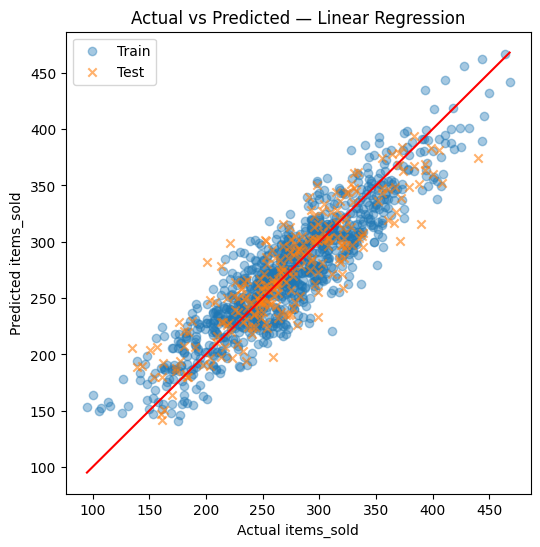

In [18]:
# PARITY PLOT 1: LINEAR REGRESSION ──
plt.figure(figsize=(6, 6))

# Plot train points
plt.scatter(y_train, y_train_pred_lr, alpha=0.4, label='Train')

# Plot test points (marker='x' makes them easy to distinguish)
plt.scatter(y_test, y_pred_lr, marker='x', alpha=0.6, label='Test')

# Perfect prediction line — if all points sat on this, we'd have 0 error
min_y = min(y_train.min(), y_train_pred_lr.min(), y_pred_lr.min())
max_y = max(y_train.max(), y_train_pred_lr.max(), y_pred_lr.max())
plt.plot([min_y, max_y], [min_y, max_y], color='red', linewidth=1.5)

plt.xlabel('Actual items_sold')
plt.ylabel('Predicted items_sold')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.show()

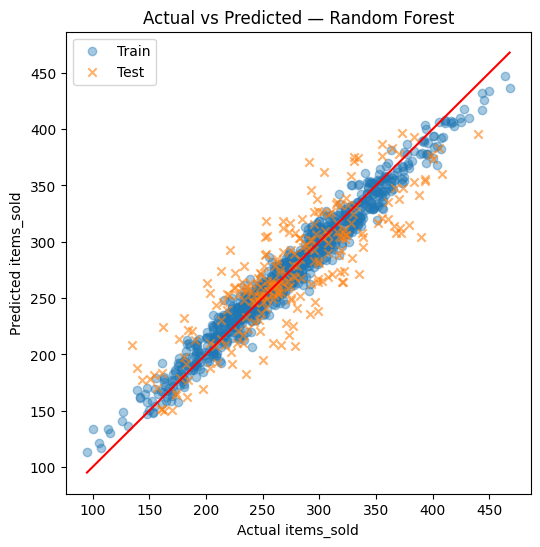

In [19]:
# PARITY PLOT 2: RANDOM FOREST

plt.figure(figsize=(6, 6))

# Plot train points
plt.scatter(y_train, y_train_pred_rf, alpha=0.4, label='Train')

# Plot test points
plt.scatter(y_test, y_pred_rf, marker='x', alpha=0.6, label='Test')

# Perfect prediction line
min_y = min(y_train.min(), y_train_pred_rf.min(), y_pred_rf.min())
max_y = max(y_train.max(), y_train_pred_rf.max(), y_pred_rf.max())
plt.plot([min_y, max_y], [min_y, max_y], color='red', linewidth=1.5)

plt.xlabel('Actual items_sold')
plt.ylabel('Predicted items_sold')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.show()

##### Feature Importance

In [20]:
# Get names from the OneHotEncoder
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_features).tolist()

# All feature names after preprocessing
all_feature_names = ohe_feature_names + numerical_features

print(f'Total features after encoding: {len(all_feature_names)}')
print('Feature names:')
for name in all_feature_names:
    print(' ', name)

Total features after encoding: 18
Feature names:
  promotion_type_bogo
  promotion_type_category_offer
  promotion_type_flat_discount
  promotion_type_free_gift
  promotion_type_loyalty_points
  location_type_rural
  location_type_semi-urban
  location_type_urban
  store_size_large
  store_size_medium
  store_size_small
  is_weekend
  is_festival
  competition_density
  year
  month
  day_of_week
  is_month_end


In [21]:
#Extracting importance scores from the trained Random Forest
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

#Creating a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'feature':    all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('All Feature Importances (sorted highest to lowest):')
print(importance_df.to_string())

All Feature Importances (sorted highest to lowest):
                          feature  importance
0                     is_festival    0.173552
1                store_size_small    0.166445
2             location_type_urban    0.109712
3                     day_of_week    0.088706
4                      is_weekend    0.066189
5             competition_density    0.064149
6             location_type_rural    0.054804
7                           month    0.051572
8                store_size_large    0.050357
9             promotion_type_bogo    0.032117
10              store_size_medium    0.029852
11  promotion_type_loyalty_points    0.025482
12                           year    0.021820
13   promotion_type_flat_discount    0.018134
14       location_type_semi-urban    0.017416
15  promotion_type_category_offer    0.012465
16       promotion_type_free_gift    0.009852
17                   is_month_end    0.007376


In [22]:
print('TOP 5 Most Influential Features:')
print (importance_df.head(5))

TOP 5 Most Influential Features:
               feature  importance
0          is_festival    0.173552
1     store_size_small    0.166445
2  location_type_urban    0.109712
3          day_of_week    0.088706
4           is_weekend    0.066189
